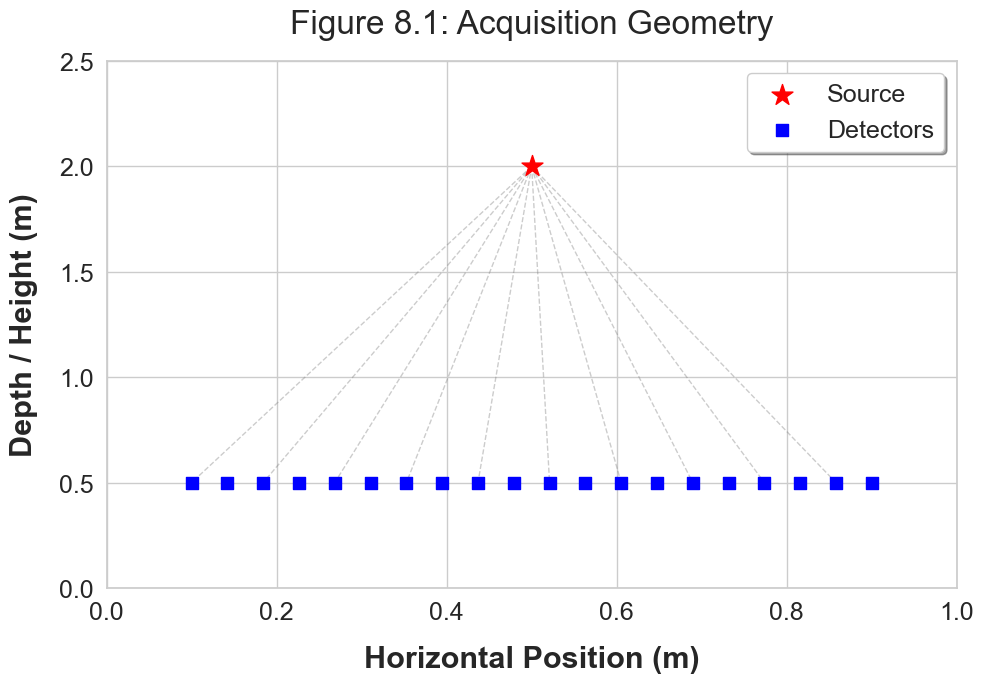

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the global aesthetic to match the manuscript's clean style
sns.set_theme(style="whitegrid")

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# 1. Coordinate Setup (Based on Figure 8.1 dimensions)
# Source position
src_x, src_y = 0.5, 2.0
# Detector array (linear array at the bottom)
det_x = np.linspace(0.1, 0.9, 20)
det_y = np.zeros_like(det_x) + 0.5

# 2. Plotting the Components
# Plot Source as a star or distinct point
ax.scatter(src_x, src_y, color='red', s=250, marker='*', label='Source', zorder=5)

# Plot Detectors as a line of points
ax.scatter(det_x, det_y, color='blue', s=80, marker='s', label='Detectors', zorder=5)

# Draw "Rays" to visualize the acquisition path
for x in det_x[::2]: # Draw every second ray for clarity
    ax.plot([src_x, x], [src_y, det_y[0]], color='gray', linestyle='--', alpha=0.4, lw=1)

# 3. CRITICAL: Font Size Enhancements
# Set font sizes for labels, titles, and ticks
font_size_large = 22
font_size_medium = 18

ax.set_xlabel("Horizontal Position (m)", fontsize=font_size_large, fontweight='bold', labelpad=15)
ax.set_ylabel("Depth / Height (m)", fontsize=font_size_large, fontweight='bold', labelpad=15)
ax.set_title("Figure 8.1: Acquisition Geometry", fontsize=font_size_large + 2, pad=20)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=font_size_medium)

# Adjust Legend size and placement
ax.legend(fontsize=font_size_medium, loc='upper right', frameon=True, shadow=True)

# Set axis limits to give the plot "breathing room"
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 2.5)

plt.tight_layout()
plt.show()

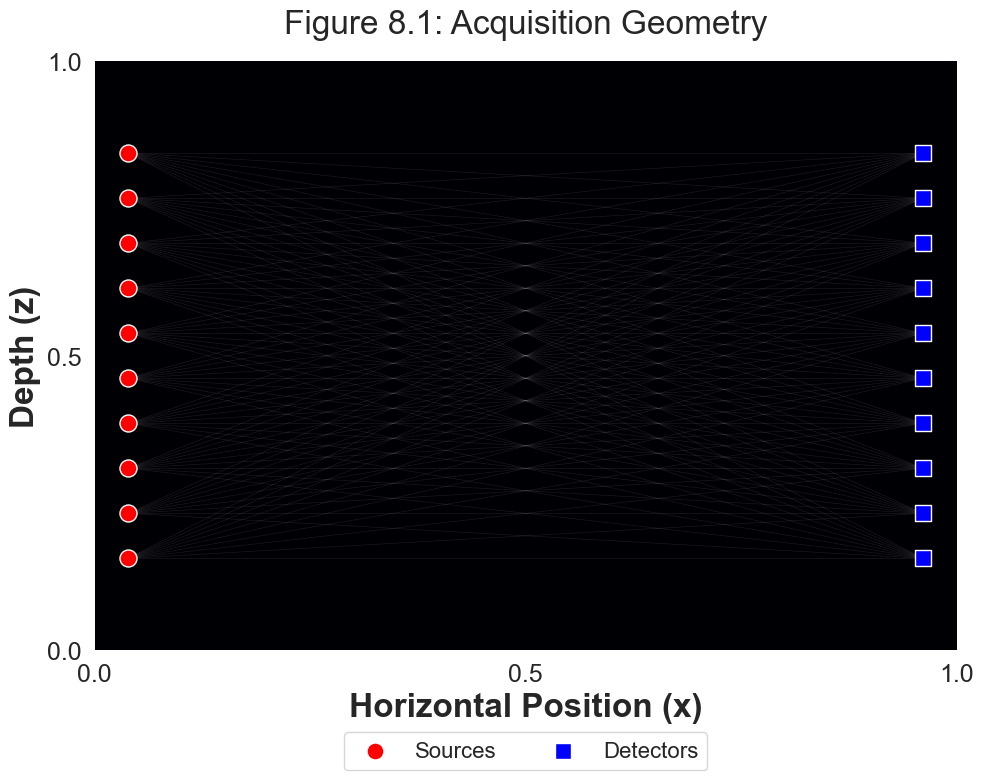

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style to white for a clean manuscript look
sns.set_theme(style="white")

# 1. Setup the Domain (Typically a 128x128 grid in the paper)
grid_size = 128
domain = np.zeros((grid_size, grid_size))

# 2. Define Source and Detector vertical positions
# Usually, they span the middle section of the boundaries
y_positions = np.linspace(20, 108, 10) 
src_x = np.zeros_like(y_positions) + 5      # Left side
det_x = np.zeros_like(y_positions) + 123    # Right side

fig, ax = plt.subplots(figsize=(10, 8))

# 3. Plot the background grid/domain
# Using 'magma' or 'gray' to mimic the velocity model background
sns.heatmap(domain, cmap='magma', cbar=False, ax=ax, xticklabels=False, yticklabels=False)

# 4. Plot Sources (Red Circles) and Detectors (Blue Squares)
ax.scatter(src_x, y_positions, color='red', s=150, marker='o', label='Sources', edgecolors='white', zorder=5)
ax.scatter(det_x, y_positions, color='blue', s=120, marker='s', label='Detectors', edgecolors='white', zorder=5)

# 5. Draw the Ray Paths (The "fan" look from Figure 8.1)
# Connecting every source to every detector
for sy in y_positions:
    for dy in y_positions:
        ax.plot([5, 123], [sy, dy], color='white', alpha=0.1, lw=0.5, zorder=1)

# 6. ENHANCED FONTS for Manuscript
font_size_label = 24
font_size_tick = 18

ax.set_xlabel("Horizontal Position (x)", fontsize=font_size_label, fontweight='bold')
ax.set_ylabel("Depth (z)", fontsize=font_size_label, fontweight='bold')
ax.set_title("Figure 8.1: Acquisition Geometry", fontsize=font_size_label, pad=20)

# Customizing ticks to represent meters (0 to 1.0)
ax.set_xticks([0, 64, 128])
ax.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=font_size_tick)
ax.set_yticks([0, 64, 128])
ax.set_yticklabels(['1.0', '0.5', '0.0'], fontsize=font_size_tick) # Depth is usually inverted

# Legend with large text
ax.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

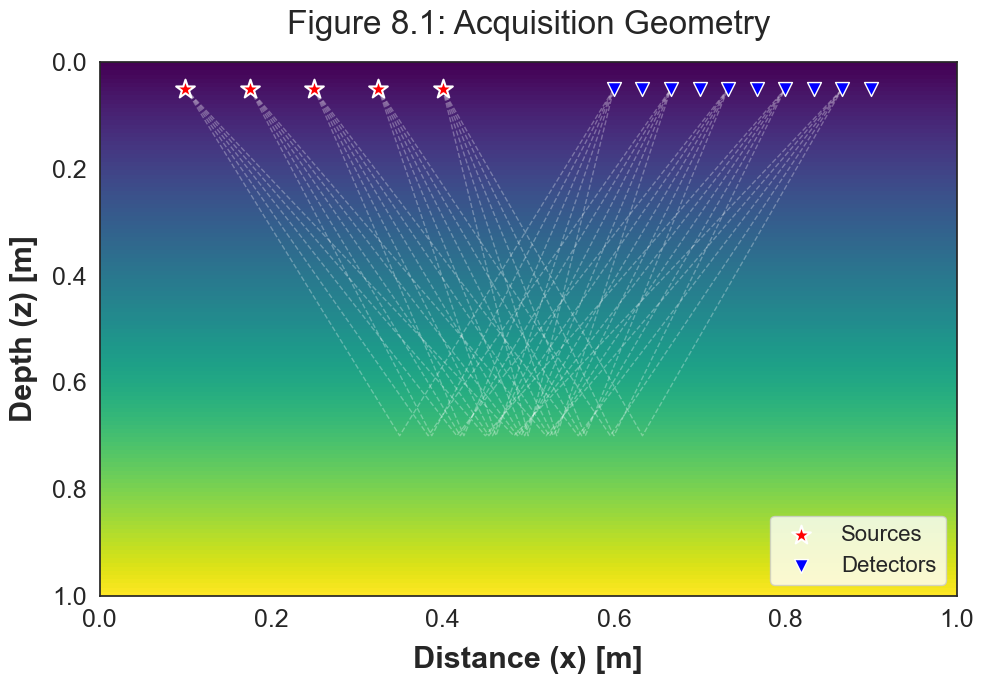

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style to white for a clean, professional look
sns.set_theme(style="white")

# 1. Setup the Domain 
grid_size = 128
# Create a gradient background to mimic a velocity model (increasing with depth)
velocity_model = np.linspace(1500, 3000, grid_size).reshape(-1, 1) * np.ones((1, grid_size))

fig, ax = plt.subplots(figsize=(10, 7))

# 2. Plot the Velocity Model Background
im = ax.imshow(velocity_model, cmap='viridis', extent=[0, 1, 1, 0], aspect='auto')

# 3. Define Surface Positions (Top boundary)
# Sources on the left half, Detectors on the right half (or interleaved)
src_x = np.linspace(0.1, 0.4, 5)
det_x = np.linspace(0.6, 0.9, 10)
surface_y = np.zeros_like(src_x) + 0.05 # Slightly below the 0.0 line for visibility

# 4. Plot Sources and Detectors
ax.scatter(src_x, surface_y, color='red', s=200, marker='*', label='Sources', 
           edgecolors='white', linewidth=1.5, zorder=5)
ax.scatter(det_x, np.zeros_like(det_x) + 0.05, color='blue', s=100, marker='v', 
           label='Detectors', edgecolors='white', linewidth=1.0, zorder=5)

# 5. Draw Reflected/Refracted Ray Paths
# These curve or "V" down to a reflector (e.g., at z=0.7)
reflector_z = 0.7
for sx in src_x:
    for dx in det_x[::2]: # Subset for visual clarity
        mid_x = (sx + dx) / 2
        ax.plot([sx, mid_x, dx], [0.05, reflector_z, 0.05], color='white', 
                alpha=0.3, lw=1, linestyle='--')

# 6. MANUSCRIPT-SCALE FONTS
font_size_label = 22
font_size_tick = 18

ax.set_xlabel("Distance (x) [m]", fontsize=font_size_label, fontweight='bold', labelpad=10)
ax.set_ylabel("Depth (z) [m]", fontsize=font_size_label, fontweight='bold', labelpad=10)
ax.set_title("Figure 8.1: Acquisition Geometry", fontsize=font_size_label + 2, pad=20)

# Ensure the Y-axis has 0 at the top (surface)
ax.set_ylim(1.0, 0.0) 
ax.tick_params(axis='both', labelsize=font_size_tick)

# Legend placement
ax.legend(fontsize=16, loc='lower right', frameon=True, facecolor='white', framealpha=0.8)

plt.tight_layout()
plt.show()

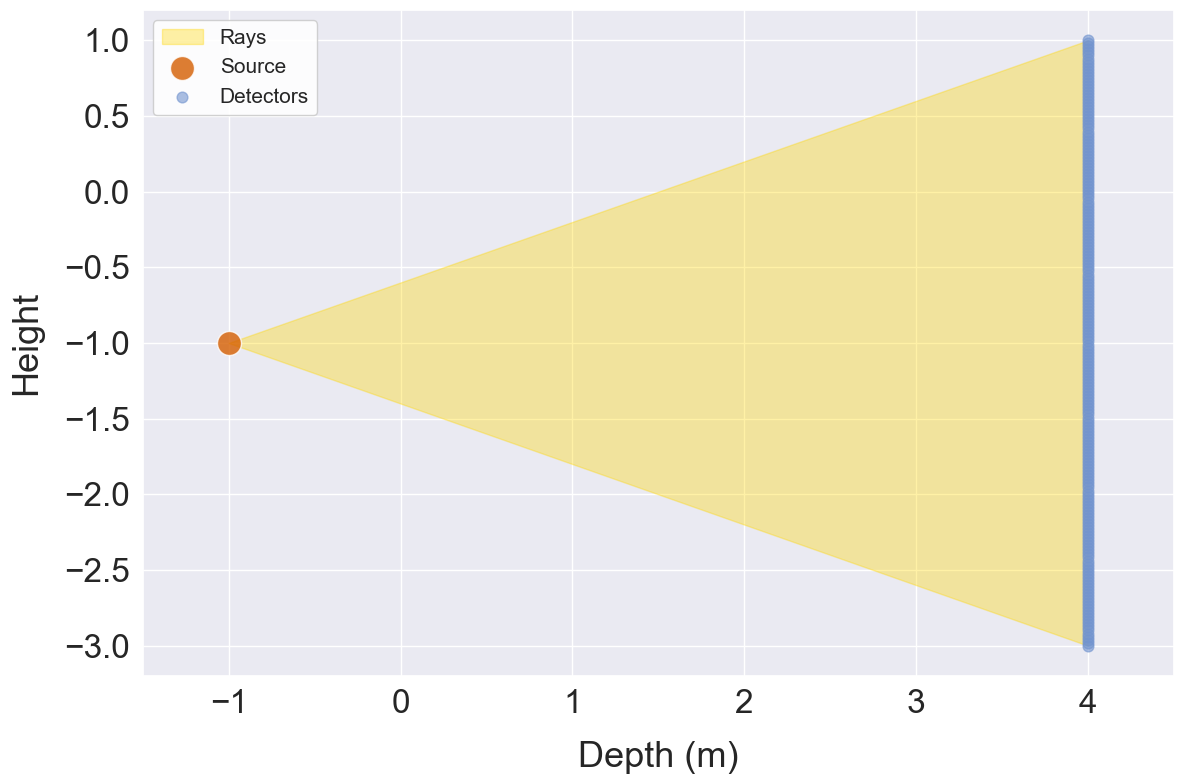

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the specific Seaborn style seen in the target image
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#EAEAF2"})

# 1. Setup Data
source_x, source_y = -1, -1.0
detector_x = 4.0
detector_y_range = np.linspace(-3.0, 1.0, 200)

fig, ax = plt.subplots(figsize=(12, 8))

# 2. Draw the Shaded Rays (The "Fan")
ax.fill_between([source_x, detector_x], 
                [source_y, -3.0], 
                [source_y, 1.0], 
                color='gold', alpha=0.35, label='Rays', zorder=1)

# 3. Plot Source and Detectors
ax.scatter(source_x, source_y, color='#D55E00', s=300, label='Source', 
           edgecolors='white', alpha=0.8, zorder=3)

ax.scatter(np.full_like(detector_y_range, detector_x), detector_y_range, 
           color='#7294CF', s=60, alpha=0.6, label='Detectors', zorder=2)

_FS_LABEL = 26
_FS_TICK = 24
_FS_TITLE = 28

# 4. Axes and Labels
# ax.set_xlabel("Depth (m)", fontsize=_FS_LABEL, fontweight='bold', labelpad=15)
# ax.set_ylabel("Height", fontsize=_FS_LABEL, fontweight='bold', labelpad=15)
ax.set_xlabel("Depth (m)", fontsize=_FS_LABEL, labelpad=15)
ax.set_ylabel("Height", fontsize=_FS_LABEL, labelpad=15)
# ax.set_title("Acquisition Geometry", fontsize=_FS_TITLE, fontweight='bold', pad=20)

ax.set_xlim(-1.5, 4.5)
ax.set_ylim(-3.2, 1.2)
ax.set_xticks([-1, 0, 1, 2, 3, 4])
ax.set_yticks([-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0])
ax.tick_params(axis='both', which='major', labelsize=_FS_TICK)

# 5. Legend
ax.legend(fontsize=_FS_LEGEND, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()
